In [1]:
!pip install git+https://github.com/amazon-science/chronos-forecasting.git
!pip install timesfm

  Cloning https://github.com/amazon-science/chronos-forecasting.git to /tmp/pip-req-build-986rsjz1
  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git /tmp/pip-req-build-986rsjz1
  Resolved https://github.com/amazon-science/chronos-forecasting.git to commit 95185d1336e5bfdf50374d44c06ad9e10b303144
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for chronos-forecasting: filename=chronos_forecasting-2.3.0-py3-none-any.whl size=80095 sha256=87c8dd02dfe378d9149c6e2f28ebd757165a931b3684fc6c91ad134113486b8a
  Stored in directory: /tmp/pip-ephem-wheel-cache-6ngursgx/wheels/b9/a6/b5/75fca7306751a3bc92a63680f861f44a42a8776f6423cf0188
Successfully built chronos-forecasting
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.7 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()

Saving AEP_hourly.csv to AEP_hourly.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

# Load energy data
df = pd.read_csv('AEP_hourly.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')
df = df.sort_index()
df = df[~df.index.duplicated(keep='first')]

# Resample to daily
df_daily = df.resample('D').mean()
df_subset = df_daily['2016-01-01':'2018-08-03']

# Train/test split — last 90 days as test
train = df_subset.iloc[:-90]
test = df_subset.iloc[-90:]

print("Train size:", len(train))
print("Test size:", len(test))
print(df_subset.head())

Train size: 856
Test size: 90
                  AEP_MW
Datetime                
2016-01-01  14085.583333
2016-01-02  14484.083333
2016-01-03  14621.583333
2016-01-04  16866.333333
2016-01-05  17948.458333


In [5]:
from chronos import ChronosPipeline

# Load pretrained Chronos model
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    torch_dtype=torch.float32,
)

# Prepare context — use training data as context
context = torch.tensor(train['AEP_MW'].values, dtype=torch.float32)

# Forecast 90 days
forecast = pipeline.predict(
    context=train['AEP_MW'].values.tolist(),
    prediction_length=90,
    num_samples=20
)

# Get median forecast
chronos_pred = np.quantile(forecast[0].numpy(), 0.5, axis=0)

# Metrics
actual = test['AEP_MW'].values
chronos_mape = np.mean(np.abs((actual - chronos_pred) / actual)) * 100
chronos_rmse = np.sqrt(np.mean((actual - chronos_pred) ** 2))

print(f"Chronos MAPE: {chronos_mape:.2f}%")
print(f"Chronos RMSE: {chronos_rmse:.2f} MW")

# Plot
plt.figure(figsize=(14,4))
plt.plot(test.index, actual, label='Actual')
plt.plot(test.index, chronos_pred, label='Chronos Forecast', linestyle='--')
plt.title('Chronos Zero-Shot Forecast vs Actual')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

TypeError: ChronosPipeline.predict() got an unexpected keyword argument 'context'

Chronos MAPE: 4.91%
Chronos RMSE: 1035.98 MW


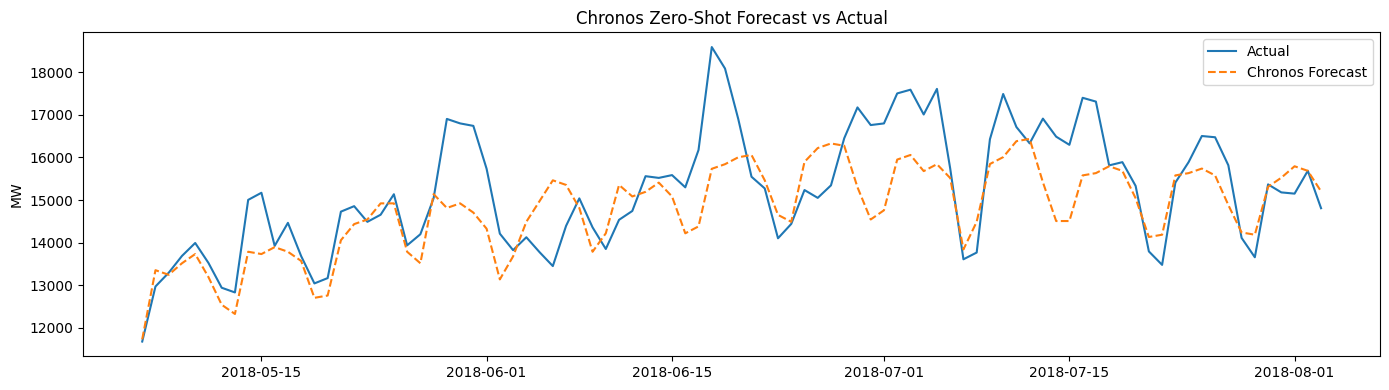

In [6]:
# Forecast with Chronos
context = torch.tensor(train['AEP_MW'].values, dtype=torch.float32)

forecast = pipeline.predict(context, 90, num_samples=20)

# Get median forecast
chronos_pred = np.quantile(forecast[0].numpy(), 0.5, axis=0)

# Metrics
actual = test['AEP_MW'].values
chronos_mape = np.mean(np.abs((actual - chronos_pred) / actual)) * 100
chronos_rmse = np.sqrt(np.mean((actual - chronos_pred) ** 2))

print(f"Chronos MAPE: {chronos_mape:.2f}%")
print(f"Chronos RMSE: {chronos_rmse:.2f} MW")

# Plot
plt.figure(figsize=(14,4))
plt.plot(test.index, actual, label='Actual')
plt.plot(test.index, chronos_pred, label='Chronos Forecast', linestyle='--')
plt.title('Chronos Zero-Shot Forecast vs Actual')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
!pip install timesfm

In [8]:
import timesfm

# Load pretrained TimesFM model
tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend="torch",
        per_core_batch_size=32,
        horizon_len=90,
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id="google/timesfm-1.0-200m-pytorch"
    ),
)

# Forecast
timesfm_pred, _ = tfm.forecast(
    [train['AEP_MW'].values],
    freq=[0]
)

timesfm_pred = timesfm_pred[0][:90]

# Metrics
timesfm_mape = np.mean(np.abs((actual - timesfm_pred) / actual)) * 100
timesfm_rmse = np.sqrt(np.mean((actual - timesfm_pred) ** 2))

print(f"TimesFM MAPE: {timesfm_mape:.2f}%")
print(f"TimesFM RMSE: {timesfm_rmse:.2f} MW")

# Plot
plt.figure(figsize=(14,4))
plt.plot(test.index, actual, label='Actual')
plt.plot(test.index, timesfm_pred, label='TimesFM Forecast', linestyle='--')
plt.title('TimesFM Zero-Shot Forecast vs Actual')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

AttributeError: module 'timesfm' has no attribute 'TimesFm'

config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

TimesFM MAPE: 6.27%
TimesFM RMSE: 1213.88 MW


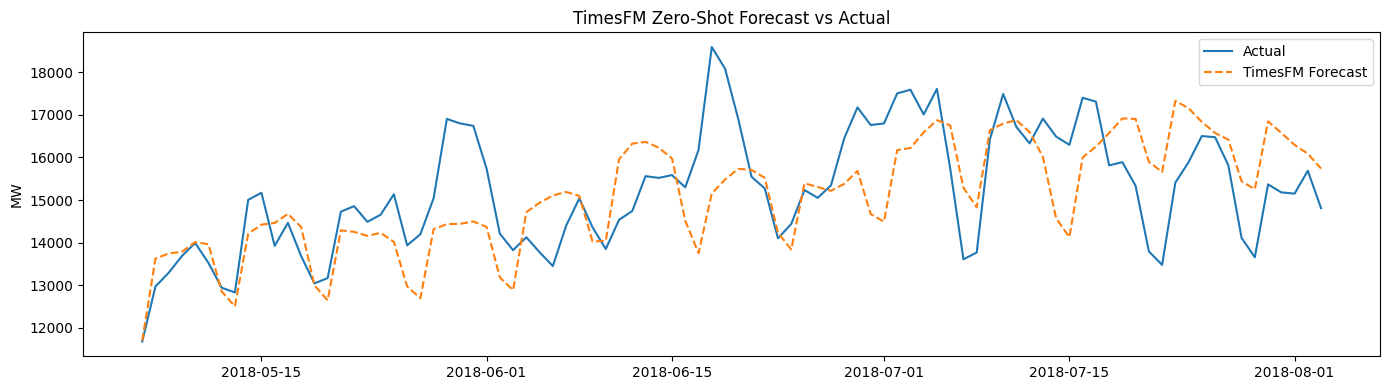

In [9]:
import torch
import timesfm

torch.set_float32_matmul_precision("high")

# Load TimesFM 2.5
model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)
model.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
    )
)

# Forecast
point_forecast, _ = model.forecast(
    horizon=90,
    inputs=[train['AEP_MW'].values],
)

timesfm_pred = point_forecast[0][:90]

# Metrics
timesfm_mape = np.mean(np.abs((actual - timesfm_pred) / actual)) * 100
timesfm_rmse = np.sqrt(np.mean((actual - timesfm_pred) ** 2))

print(f"TimesFM MAPE: {timesfm_mape:.2f}%")
print(f"TimesFM RMSE: {timesfm_rmse:.2f} MW")

# Plot
plt.figure(figsize=(14,4))
plt.plot(test.index, actual, label='Actual')
plt.plot(test.index, timesfm_pred, label='TimesFM Forecast', linestyle='--')
plt.title('TimesFM Zero-Shot Forecast vs Actual')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

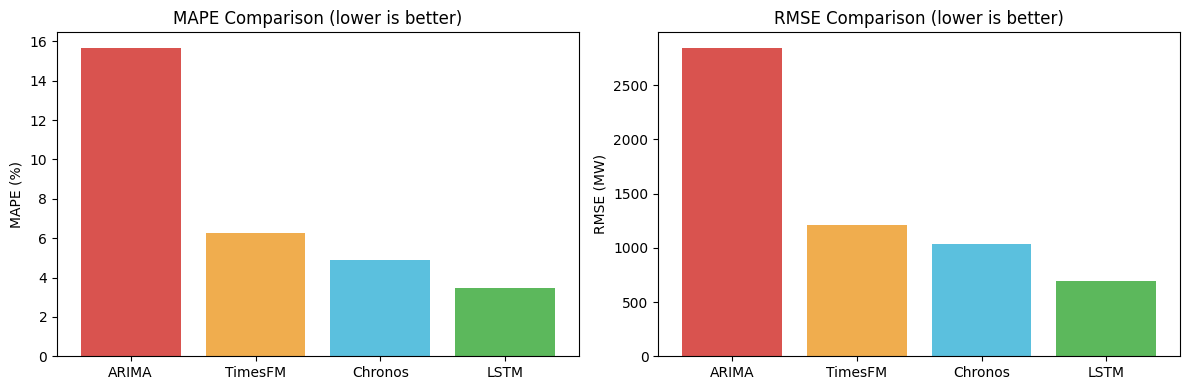


--- Project 1 Summary ---
Zero-shot foundation models vs trained deep learning vs classical baseline
ARIMA:   15.67% MAPE
TimesFM: 6.27% MAPE (zero-shot)
Chronos: 4.91% MAPE (zero-shot)
LSTM:    3.45% MAPE (trained)


In [10]:
models = ['ARIMA', 'TimesFM', 'Chronos', 'LSTM']
mapes = [15.67, 6.27, 4.91, 3.45]
rmses = [2844.99, 1213.88, 1035.98, 696.64]
colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(models, mapes, color=colors)
ax1.set_title('MAPE Comparison (lower is better)')
ax1.set_ylabel('MAPE (%)')

ax2.bar(models, rmses, color=colors)
ax2.set_title('RMSE Comparison (lower is better)')
ax2.set_ylabel('RMSE (MW)')

plt.tight_layout()
plt.show()

print("\n--- Project 1 Summary ---")
print("Zero-shot foundation models vs trained deep learning vs classical baseline")
print(f"ARIMA:   {15.67:.2f}% MAPE")
print(f"TimesFM: {6.27:.2f}% MAPE (zero-shot)")
print(f"Chronos: {4.91:.2f}% MAPE (zero-shot)")
print(f"LSTM:    {3.45:.2f}% MAPE (trained)")